In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from environments.EMS_env import ContinousEMSEnv, normalizationWrapper

from stable_baselines3 import TD3, PPO, SAC
from stable_baselines3.common.noise import NormalActionNoise, OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.logger import configure

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'cm'

In [2]:
tmp_path = "training_results/ems"
algorithms = ["PPO", "TD3", "SAC"]
env = ContinousEMSEnv()
env = normalizationWrapper(env)
s, _ = env.reset()

In [3]:
directories = ['training_results/ems/ems/PPO/progress.csv',
               'training_results/ems/ems/TD3/progress.csv',
               'training_results/ems/ems/SAC/progress.csv']
ppo_stats = pd.read_csv(directories[0])
td3_stats = pd.read_csv(directories[1])
sac_stats = pd.read_csv(directories[2])

In [4]:
ppo_rews = ppo_stats['rollout/ep_rew_mean'].to_numpy()
td3_rews = td3_stats['rollout/ep_rew_mean'].to_numpy()
sac_rews = sac_stats['rollout/ep_rew_mean'].to_numpy()

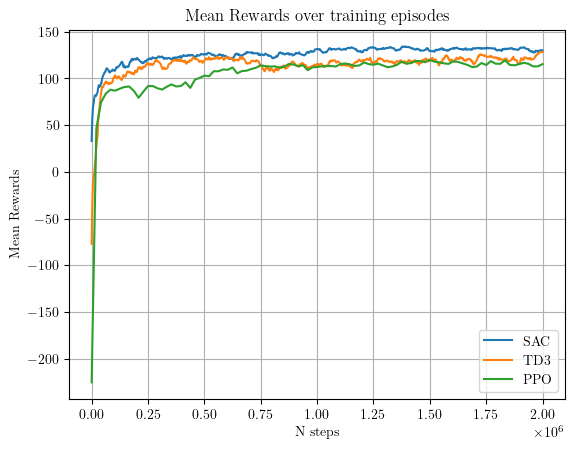

In [5]:
n1 = np.linspace(1,2e6, len(ppo_stats))
n2 = np.linspace(1,2e6, len(td3_stats))
n3 = np.linspace(1,2e6, len(sac_stats))
plt.plot(n3, sac_rews, label = 'SAC')
plt.plot(n2, td3_rews, label = 'TD3')
plt.plot(n1, ppo_rews, label = 'PPO')
plt.title('Mean Rewards over training episodes')
plt.legend()
plt.xlabel('N steps')
plt.ylabel('Mean Rewards')
plt.grid()
plt.savefig('learning_curves.png', dpi = 300)

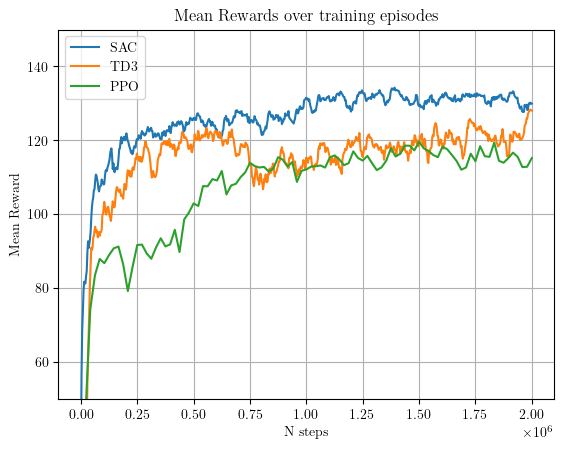

In [6]:
n1 = np.linspace(1,2e6, len(ppo_stats))
n2 = np.linspace(1,2e6, len(td3_stats))
n3 = np.linspace(1,2e6, len(sac_stats))
plt.plot(n3, sac_rews, label = 'SAC')
plt.plot(n2, td3_rews, label = 'TD3')
plt.plot(n1, ppo_rews, label = 'PPO')
plt.title('Mean Rewards over training episodes')
plt.legend()
plt.xlabel('N steps')
plt.ylabel('Mean Reward')
plt.ylim([50, 150])
plt.grid()
plt.savefig('learning_curves_zoomed.png', dpi = 300)

In [5]:
n_days = 30
options = {"mode": "eval"}
PPO_data = {}
TD3_data = {}
SAC_data = {}

for alg in algorithms:
    if alg == "PPO":
        model = PPO.load('training_results/ems/ems/PPO/PPO_du_norm_1.zip')
    elif alg == "TD3":
        model = TD3.load('training_results/ems/ems/TD3/TD3_du_norm_1.zip')
    else:
        model = SAC.load('training_results/ems/ems/SAC/SAC_du_norm_1.zip')
    responses=np.zeros((env.observation_space.low.shape[-1], n_days*144+1))
    rewards = np.zeros(n_days*144)
    actions = np.zeros((2,n_days*144))
    t_s, s = env.reset(options=options)
    responses[:,0] = s
    for i in range(n_days*144):
        action = model.predict(t_s)[0]
        t_s, rew, d, w, s = env.step(action)
        responses[:,i+1] = s
        rewards[i] = rew
        actions[:,i] = action    
    if alg == "PPO":
        PPO_data['responses'] = responses
        PPO_data['rewards'] = rewards
        PPO_data['actions'] = actions
    elif alg == "TD3":
        TD3_data['responses'] = responses
        TD3_data['rewards'] = rewards
        TD3_data['actions'] = actions
    else:
        SAC_data['responses'] = responses
        SAC_data['rewards'] = rewards
        SAC_data['actions'] = actions

/home/lyapunov/anaconda3/envs/RL/lib/python3.8/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: Can't get attribute '_function_setstate' on <module 'cloudpickle.cloudpickle' from '/home/lyapunov/anaconda3/envs/RL/lib/python3.8/site-packages/cloudpickle/cloudpickle.py'>
  warnings.warn(
/home/lyapunov/anaconda3/envs/RL/lib/python3.8/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: Can't get attribute '_function_setstate' on <module 'cloudpickle.cloudpickle' from '/home/lyapunov/anaconda3/envs/RL/lib/python3.8/site-packages/cloudpickle/cloudpickle.py'>
  warnings.warn(
/home/lyapunov/anaconda3/envs/RL/lib/python3.8/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object lr_

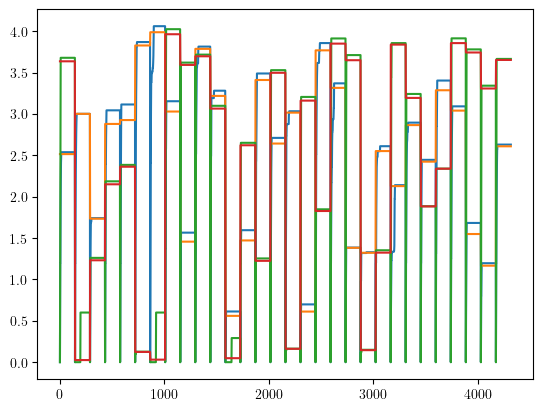

In [6]:
responses1 = PPO_data['responses']
responses2 = TD3_data['responses']
responses3 = SAC_data['responses']

plt.plot(responses1[1,:-1])
plt.plot(responses1[0,:-1])

plt.plot(responses2[1,:-1])
plt.plot(responses2[0,:-1])

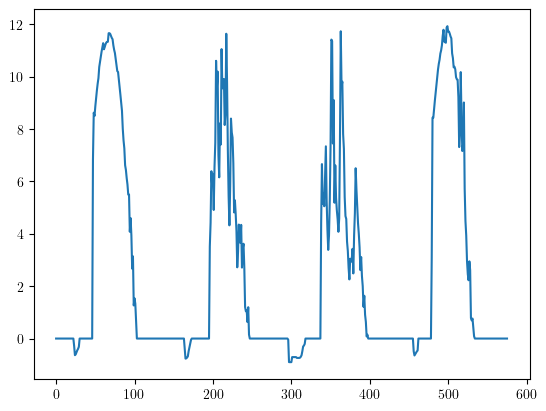

In [17]:
plt.plot(responses1[-1,288*2:288*4])

In [27]:
a = np.zeros(n_days)
for i in range(1, n_days):
    a[i] = responses3[0,144*i-1] - responses3[1,144*i-1]
    

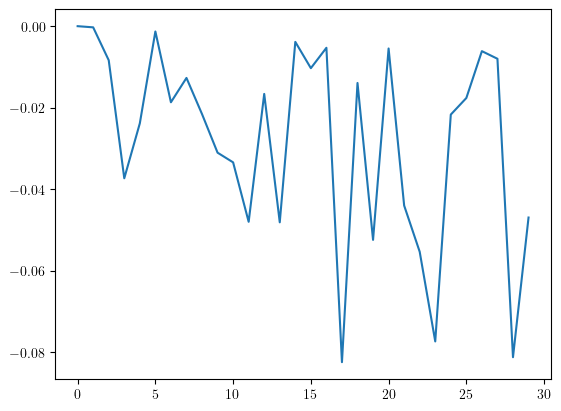

In [28]:
plt.plot(a)

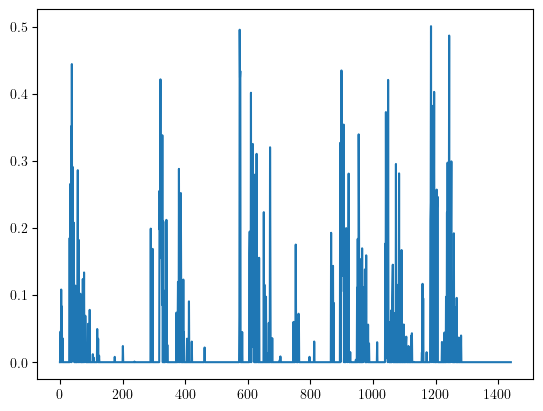

In [15]:
plt.plot(responses[4,:])

Text(0.5, 1.0, 'rewards: 70.65035207914568')

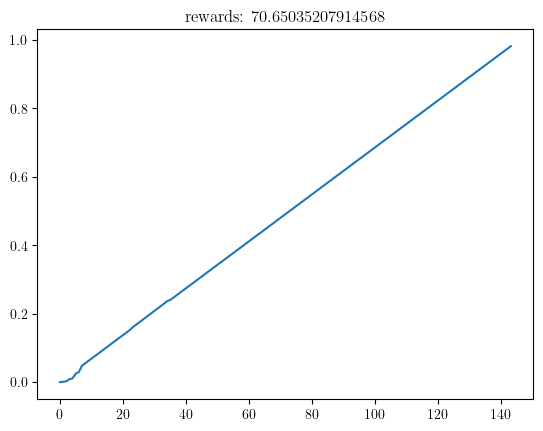

In [19]:
plt.plot(rewards)
plt.title(f"rewards: {np.sum(rewards)}")

In [20]:
def sat_cumsum(x):
    sum_ = 0
    y = np.zeros_like(x)
    for i in range(len(x)):
        sum_ += x[i]
        sum_ = np.clip(sum_,0,1)
        y[i] = sum_
    return y    

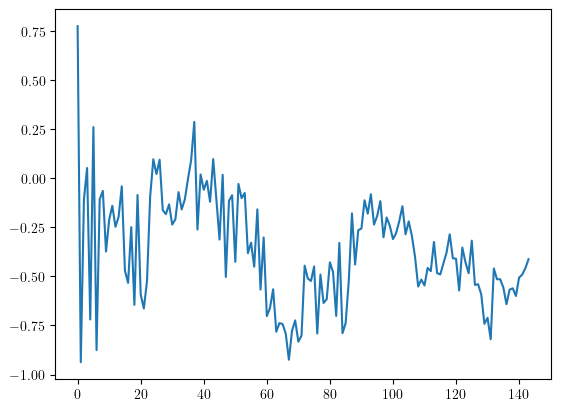

In [23]:
#plt.plot(responses[3,:288])
#plt.plot(sat_cumsum(actions1[:144]))
plt.plot(actions1)

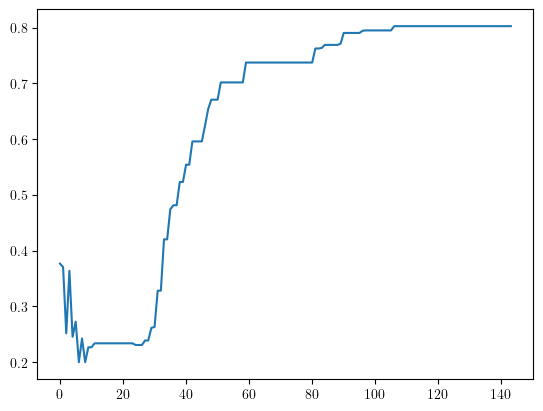

In [24]:
plt.plot(responses[3,:-1])

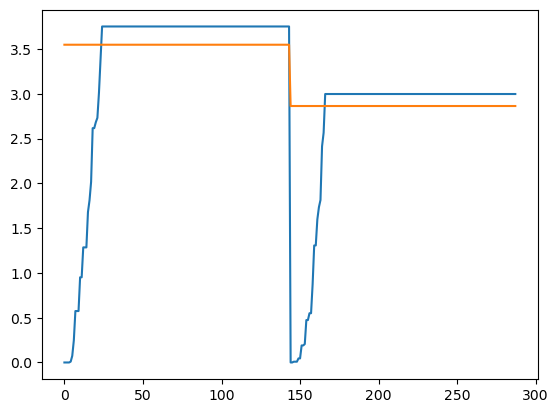

In [39]:
states, actions, rew = env.sample_trajectory(lambda x: model.predict(x)[0])
plt.plot(states[:-1,1])
plt.plot(states[:-1,0])

In [30]:
plt.plot(responses[:,7])
plt.plot(states[:,8])

NameError: name 'states' is not defined

In [29]:
T_inv = np.linalg.inv(env.transform)
env.show_sample(lambda x: model.predict(np.matmul(T_inv, x))[0])
fig = env.get_figure()
fig.savefig("agora_sim.png")

In [11]:
stats = pd.read_csv(tmp_path+"/progress.csv")


(60.0, 100.0)

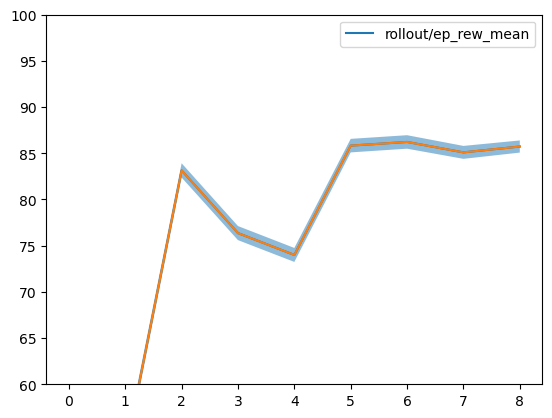

In [23]:
stats.plot(y = "rollout/ep_rew_mean")

ep_rwd_mean = stats["rollout/ep_rew_mean"]
ep_rwd_std = stats["train/std"]
plt.plot(ep_rwd_mean)
plt.fill_between(range(0,len(ep_rwd_mean)), ep_rwd_mean-ep_rwd_std, ep_rwd_mean+ep_rwd_std, alpha=0.5)
plt.ylim([60,100])

In [12]:
stats.head(5)

,time/total_timesteps,train/std,time/iterations,train/value_loss,train/clip_fraction,train/policy_gradient_loss,time/fps,time/time_elapsed,rollout/ep_len_mean,train/clip_range,train/entropy_loss,train/learning_rate,rollout/ep_rew_mean,train/loss,train/n_updates,train/explained_variance,train/approx_kl
0,20480,0.775678,10,49.735528,0.128174,-0.005355,851,24,288.0,0.2,-2.326335,0.001,-190.168983,26.457687,90,-0.000060,0.011725
1,40960,0.812221,20,14.223521,0.032471,-0.003240,848,48,288.0,0.2,-2.370625,0.001,52.562854,3.392765,190,0.556316,0.003907
2,61440,0.773654,30,7.484913,0.041406,-0.003579,848,72,288.0,0.2,-2.238383,0.001,83.145494,3.641592,290,0.921436,0.007175
3,81920,0.761908,40,8.960387,0.071094,-0.001853,846,96,288.0,0.2,-2.216065,0.001,76.361634,2.376076,390,0.900291,0.006660
4,102400,0.756763,50,3.808346,0.087549,-0.002487,820,124,288.0,0.2,-2.132692,0.001,73.997799,1.378352,490,0.920858,0.009830
